In [12]:
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from numpyro import distributions as dist
from numpyro.infer import NUTS, MCMC
import matplotlib.pyplot as plt
import seaborn as sns

from projection_vi import ComponentwiseFlow, MFVIStep

Consider the 2-dimensional target distribution $p$ with density given by
$$
\log\frac{p(x)}{\gamma(x)} = \beta \sin(x_1) \cdot \sin(2x_2) ,
$$
where $\gamma$ is the standard normal distribution.

In [13]:
beta = 2.5

rot = jnp.array([[1, 1], [-1, 1]]) / jnp.sqrt(2)

class Target:
    def __init__(self, d=2, beta=0.1):
        self.d = d
        self.beta = beta

    def logp_fn(self, x):
        return -0.5 * (x[0]**2 + x[1]**2) - self.beta * jnp.sin(x[0]) * jnp.sin(2 * x[1])
    
def _numpyro_model():
    x = numpyro.sample("x", dist.MultivariateNormal(jnp.zeros(2), jnp.eye(2)))
    numpyro.factor("interaction",  - beta * jnp.sin(x[0]) * jnp.sin(2 * x[1]))

d = 2
target = Target(beta=beta)
logp_fn = jax.jit(target.logp_fn)

In [14]:
key = jax.random.PRNGKey(0)
kernel = NUTS(_numpyro_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=10000, num_chains=1, progress_bar=True)
mcmc.run(key)          
mcmc_samples = mcmc.get_samples()['x']

sample: 100%|██████████| 10500/10500 [00:01<00:00, 7393.27it/s, 7 steps of size 4.28e-01. acc. prob=0.90]


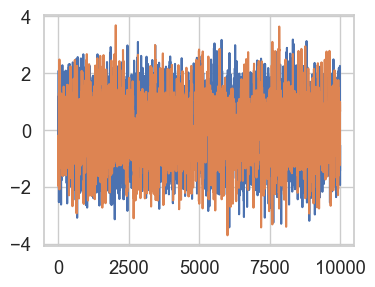

In [15]:
plt.figure(figsize=(4, 3))
plt.plot(mcmc_samples[:, 0])
plt.plot(mcmc_samples[:, 1])

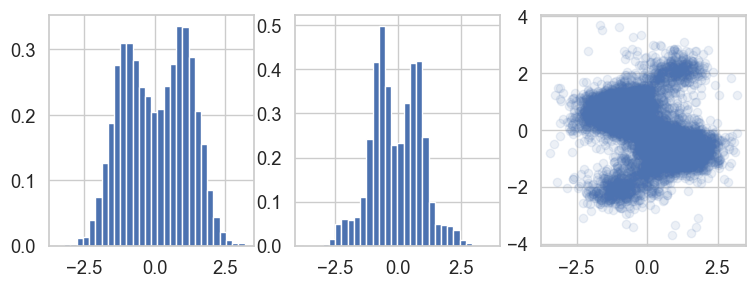

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].hist(mcmc_samples[:, 0], 30, density=True)
ax[1].hist(mcmc_samples[:, 1], 30, density=True)
ax[2].scatter(mcmc_samples[:, 0], mcmc_samples[:, 1], alpha=0.1)

In [17]:
score_fn = jax.jit(jax.grad(logp_fn))
gaussian_samples = jax.random.normal(key=jax.random.key(1), shape=(2000, d))
relative_scores = jax.vmap(score_fn)(gaussian_samples) + gaussian_samples
S = np.cov(relative_scores.T)
rot_S = np.linalg.eigh(S)[1]
print(rot_S)

H = relative_scores.T @ gaussian_samples / gaussian_samples.shape[0]
H = .5 * (H + H.T)
rot_H = np.linalg.eigh(H)[1]
print(rot_H)

[[-9.99999996e-01 -8.83648580e-05]
 [-8.83648580e-05  9.99999996e-01]]
[[-0.75780016 -0.6524867 ]
 [-0.6524867   0.75780016]]


In [18]:
flow = ComponentwiseFlow(d, num_bins=10, range_min=-5., range_max=5.)

def rotated_logp_H(x):
    return target.logp_fn(rot_H @ x)

def rotated_logp_S(x):
    return target.logp_fn(rot_S @ x)

params_H, losses_H = MFVIStep(rotated_logp_H, d=d, flow=flow, nsample=2000, key=jax.random.key(2), learning_rate=0.01, max_iter=1000)
params_S, losses_S = MFVIStep(rotated_logp_S, d=d, flow=flow, nsample=2000, key=jax.random.key(2), learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2671.82it/s]


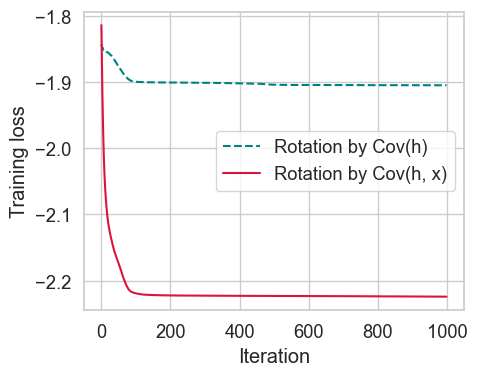

In [23]:
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.figure(figsize=(5, 4))
plt.plot(losses_S, label='Rotation by Cov(h)', c='teal', ls='--')
plt.plot(losses_H, label='Rotation by Cov(h, x)', c='crimson')
plt.legend(loc='right')
plt.ylabel('Training loss')
plt.xlabel('Iteration')
plt.tight_layout()
plt.savefig('experiments/compare_rotations/pure_interaction_training_loss.pdf')

In [20]:
base_samples = jax.random.normal(jax.random.key(2), (2000, d))
rotated_samples_H, _ = flow.apply(params_H, base_samples)
samples_H = jax.vmap(lambda x: rot_H @ x)(rotated_samples_H)

rotated_samples_S, _ = flow.apply(params_S, base_samples)
samples_S = jax.vmap(lambda x: rot_S @ x)(rotated_samples_S)

In [21]:
v1 = jnp.array([1, -1]) / jnp.sqrt(2)
mcmc_samples_v1 = mcmc_samples @ v1
samples_H_v1 = samples_H @ v1
samples_S_v1 = samples_S @ v1

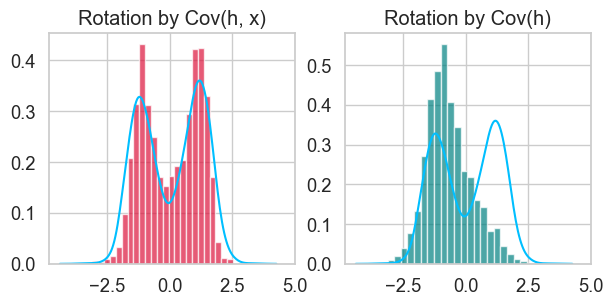

In [22]:
sns.set_theme(style='whitegrid', font_scale=1.2)
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex=True)
bins = 30
alpha = .7

sns.kdeplot(ax=ax[0], x=mcmc_samples_v1, c='deepskyblue')
ax[0].hist(samples_H_v1, density=True, alpha=alpha, bins=bins, color='crimson')
ax[0].set_title('Rotation by Cov(h, x)')

sns.kdeplot(ax=ax[1], x=mcmc_samples_v1, c='deepskyblue')
ax[1].hist(samples_S_v1, density=True, alpha=alpha, bins=bins, color='teal')
ax[1].set_title('Rotation by Cov(h)')

for a in ax.flat:
    a.set_ylabel('')

plt.savefig('experiments/compare_rotations/pure_interaction_histograms.pdf')